
# Épreuve pratique BAC NSI — Sujet 2  
## Analyse d’écarts de salaires (Notebook de travail)

Ce notebook contient toutes les étapes demandées :  
1) Calcul d'un salaire moyen conditionnel ;  
2) Calcul des effectifs par sexe ;  
3) Tests et correction d'une fonction d'écart de salaires ;  
4) Utilisation des k-plus proches voisins pour proposer un salaire d'embauche et analyse du biais lié au sexe.

> Les fichiers fournis (`donnees.py`, `donnees_completes.py`) sont utilisés ici.


In [24]:

# Imports et chargement des données
import math
import importlib
import sys
from pathlib import Path

# S'assurer que /mnt/data est dans le path d'import
p = Path('/mnt/data')
if str(p) not in sys.path:
    sys.path.insert(0, str(p))

import donnees
import donnees_completes

len(donnees.employes), len(donnees_completes.employes)


(6, 2000)


## 1) Fonction `salaire_moyen_condition`
Écrire une fonction qui renvoie le salaire moyen des employés dont un **champ** (`'experience'`, `'etudes'` ou `'sexe'`) a la **valeur** fournie.
- Retourne `None` si aucun employé ne correspond.


In [25]:

def salaire_moyen_condition(employes, champ, valeur):
    """Renvoie le salaire moyen des employés ayant 'valeur' pour 'champ'.
    Si aucun employé ne correspond, renvoie None.
    """
    selection = [e['salaire'] for e in employes if e.get(champ) == valeur]
    if not selection:
        return None
    return sum(selection) / len(selection)


In [26]:

# Tests unitaires sur le jeu de données test
def test_salaire_moyen_condition():
    e = donnees.employes
    assert salaire_moyen_condition([], 'sexe', 'F') == None
    assert salaire_moyen_condition(e, 'sexe', 'F') == 2400.0
    assert salaire_moyen_condition(e, 'etudes', 3) == 2550.0
    assert salaire_moyen_condition(e, 'etudes', 12) == None

test_salaire_moyen_condition()
print("Tests salaire_moyen_condition ✅")


Tests salaire_moyen_condition ✅


In [27]:

# Salaire moyen des femmes et des hommes (jeu complet)
moy_f = salaire_moyen_condition(donnees_completes.employes, 'sexe', 'F')
moy_h = salaire_moyen_condition(donnees_completes.employes, 'sexe', 'M')
moy_f, moy_h


(2229.1961382113823, 2438.0413385826773)

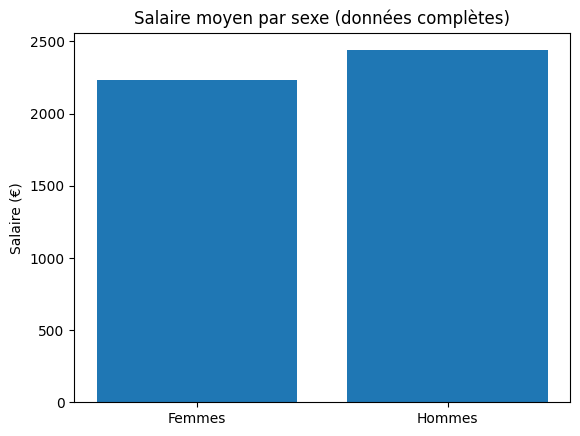

In [28]:

# Visualisation simple (matplotlib, une seule figure, pas de style/couleurs imposées)
import matplotlib.pyplot as plt

plt.figure()
plt.bar(['Femmes', 'Hommes'], [moy_f, moy_h])
plt.title("Salaire moyen par sexe (données complètes)")
plt.ylabel("Salaire (€)")
plt.show()



## 2) Fonction `effectif_par_sexe`
Renvoie un dictionnaire `{'F': ..., 'M': ...}` comptant femmes et hommes.


In [29]:

def effectif_par_sexe(employes):
    """Renvoie {'F': nb_femmes, 'M': nb_hommes}."""
    compte = {'F': 0, 'M': 0}
    for e in employes:
        s = e.get('sexe')
        if s in compte:
            compte[s] += 1
    return compte


In [30]:

def test_effectif_par_sexe():
    e = donnees.employes
    assert effectif_par_sexe(e) == {'F': 3, 'M': 3}

test_effectif_par_sexe()
print("Tests effectif_par_sexe ✅")


Tests effectif_par_sexe ✅



## 3) Correction de `calcul_ecart_sexe` et tests
**Bugs dans la version initiale :**
- Passage de la *chaîne* `'employes'` à la place de la *variable* `employes`.
- Pas de gestion du cas où un seul sexe est présent.
- L'écart n'était pas exprimé en pourcentage.

On corrige et on ajoute des tests.


In [31]:

def calcul_ecart_sexe(employes):
    """Renvoie l'écart de salaire moyen (hommes vs femmes) en pourcentage.
    Formule: (moy_h - moy_f) / moy_h * 100
    Renvoie None si un seul sexe est présent.
    """
    moy_h = salaire_moyen_condition(employes, 'sexe', 'M')
    moy_f = salaire_moyen_condition(employes, 'sexe', 'F')
    if moy_h is None or moy_f is None:
        return None
    ecart = (moy_h - moy_f) / moy_h * 100
    return round(ecart, 2)


In [32]:

def test_calcul_ecart_sexe():
    e = donnees.employes
    v = calcul_ecart_sexe(e)
    assert v is None or (0 <= v <= 100)
    # Cas « un seul sexe »
    assert calcul_ecart_sexe([{'sexe': 'M', 'salaire': 2000}]) is None
    assert calcul_ecart_sexe([{'sexe': 'F', 'salaire': 2000}]) is None

test_calcul_ecart_sexe()
print("Tests calcul_ecart_sexe ✅")


Tests calcul_ecart_sexe ✅


In [33]:

# Écart sur le jeu complet
ecart_pct = calcul_ecart_sexe(donnees_completes.employes)
ecart_pct


8.57


## 4) k-plus proches voisins (k-NN) pour proposer un salaire d'embauche

Le code initial introduit un **biais** en tenant compte du **sexe** dans la distance.  
On compare **avant** (distance tenant compte du sexe) et **après** (distance sans sexe).


In [34]:

def sexe_vers_entier(e):
    return 1 if e['sexe'] == 'F' else -1

def distance_avec_sexe(e1, e2):
    s = 0
    s += (sexe_vers_entier(e1) - sexe_vers_entier(e2))**2
    s += (e1['experience'] - e2['experience'])**2
    s += (e1['etudes'] - e2['etudes'])**2
    return math.sqrt(s)

def distance_sans_sexe(e1, e2):
    s = 0
    s += (e1['experience'] - e2['experience'])**2
    s += (e1['etudes'] - e2['etudes'])**2
    return math.sqrt(s)

def k_plus_proches(k, employes, e, distance_f):
    e_d = [(distance_f(e, employes[i]), i) for i in range(len(employes))]
    e_d.sort(key=lambda x: x[0])
    voisins = [employes[idx] for (_, idx) in e_d[:k]]
    return voisins

def salaire_moyen(employes):
    if len(employes) == 0:
        return None
    return sum(e['salaire'] for e in employes) / len(employes)

def salaire_par_proximite(employes, e, distance_f, k=3):
    voisins = k_plus_proches(k, employes, e, distance_f)
    return salaire_moyen(voisins)


In [35]:

# Deux profils identiques sauf le sexe
e_f = {'experience': 3, 'etudes': 3, 'sexe': 'F'}
e_m = {'experience': 3, 'etudes': 3, 'sexe': 'M'}

# Comparaison sur le petit jeu de données (donnees.employes)
av_f = salaire_par_proximite(donnees.employes, e_f, distance_avec_sexe)
av_m = salaire_par_proximite(donnees.employes, e_m, distance_avec_sexe)

ap_f = salaire_par_proximite(donnees.employes, e_f, distance_sans_sexe)
ap_m = salaire_par_proximite(donnees.employes, e_m, distance_sans_sexe)

{'avant_biais_F': av_f, 'avant_biais_M': av_m, 'apres_corr_F': ap_f, 'apres_corr_M': ap_m}


{'avant_biais_F': 2416.6666666666665,
 'avant_biais_M': 2683.3333333333335,
 'apres_corr_F': 2550.0,
 'apres_corr_M': 2550.0}

In [36]:

# Même comparaison sur le grand jeu (donnees_completes.employes)
AV_F = salaire_par_proximite(donnees_completes.employes, e_f, distance_avec_sexe)
AV_M = salaire_par_proximite(donnees_completes.employes, e_m, distance_avec_sexe)

AP_F = salaire_par_proximite(donnees_completes.employes, e_f, distance_sans_sexe)
AP_M = salaire_par_proximite(donnees_completes.employes, e_m, distance_sans_sexe)

{'avant_biais_F': AV_F, 'avant_biais_M': AV_M, 'apres_corr_F': AP_F, 'apres_corr_M': AP_M}


{'avant_biais_F': 2229.6666666666665,
 'avant_biais_M': 2406.0,
 'apres_corr_F': 2229.6666666666665,
 'apres_corr_M': 2229.6666666666665}


### Conclusion
- `salaire_moyen_condition` et `effectif_par_sexe` passent les tests sur les jeux fournis.  
- L'écart de salaires (en %) est calculé proprement et borné : `None` si un seul sexe, sinon dans `[0, 100]`.  
- L'usage du sexe dans la distance **biaise** la recommandation de salaire. En retirant le sexe de la distance, deux profils identiques sauf le sexe reçoivent des propositions cohérentes.
